# El espacio-k: dónde vive el contraste y dónde vive el borde

Notebook reproducible del artículo. Todo corre sobre un fantasma sintético con
**verdad conocida**, de modo que cada error reportado es un error real medido
contra la referencia, no una comparación entre dos reconstrucciones.

Contenido:

1. Fantasma y física de la señal spin-echo
2. El contraste no es densidad: barrido TR/TE
3. Anatomía del espacio-k: energía radial
4. Truncamiento: resolución, tiempo y SSIM
5. La tarea que importa: detección de lesiones (AUC)
6. Timbre de Gibbs: verificación numérica
7. Tiempos de adquisición

In [1]:
import sys, os, json
# el notebook debe correr desde la raiz del repositorio
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, 'src')
import numpy as np
import matplotlib.pyplot as plt

import mri
import experimentos as E
import figuras

N = 256
FOV_MM = 240.0
np.set_printoptions(precision=4, suppress=True)
print('numpy', np.__version__)

numpy 2.4.4


## 1. Fantasma y física de la señal

Cada píxel tiene una etiqueta de tejido; de ahí salen los mapas de PD, T1 y T2. La señal de un spin-echo es

$$S = \rho \,(1 - e^{-TR/T_1})\, e^{-TE/T_2}$$

In [2]:
lab = mri.fantasma_etiquetas(N)
print(f'{"etiqueta":>8}  {"tejido":28s} {"PD":>5} {"T1(ms)":>8} {"T2(ms)":>8} {"pixeles":>8}')
for k, (nom, pd_, t1_, t2_) in mri.TEJIDOS.items():
    print(f'{k:>8}  {nom:28s} {pd_:5.2f} {t1_:8.0f} {t2_:8.0f} {(lab == k).sum():8d}')
print(f'\nresolucion nominal = {FOV_MM/N:.3f} mm/pixel')

etiqueta  tejido                          PD   T1(ms)   T2(ms)  pixeles
       0  aire                          0.00        1        1    34393
       1  grasa subcutanea              1.00      250       70     3144
       2  hueso cortical                0.10      500       20     3248
       3  liquido cefalorraquideo       1.00     4000     2000     3316
       4  materia gris                  0.85     1000      100     9370
       5  materia blanca                0.75      650       80    11930
       6  lesion (edema)                0.90     1200      150      135

resolucion nominal = 0.938 mm/pixel


In [3]:
fig, axs = plt.subplots(1, 4, figsize=(13, 3.2))
pd_, t1_, t2_ = mri.mapas_tejido(lab)
for ax, (tit, m) in zip(axs, [('etiquetas', lab), ('PD', pd_),
                              ('T1 (ms)', t1_), ('T2 (ms)', t2_)]):
    im = ax.imshow(m, cmap='viridis'); ax.set_title(tit); ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.show()

## 2. El contraste no es densidad

Mismo tejido, mismo escáner: lo que cambia es TR y TE.

In [4]:
for p, (TR, TE) in mri.PROTOCOLOS.items():
    img = mri.imagen_protocolo(lab, p)
    print(f'{p:5s} TR={TR:6.0f} TE={TE:6.0f}  '
          f'C(lesion/MB)={mri.contraste(img, lab, 6, 5):+.4f}  '
          f'C(MG/MB)={mri.contraste(img, lab, 4, 5):+.4f}  '
          f'C(LCR/MB)={mri.contraste(img, lab, 3, 5):+.4f}')

pd_only = (0.90 - 0.75) / (0.90 + 0.75)
print(f'\nSolo con densidad protonica (analogo a CT): C(lesion/MB) = {pd_only:+.4f}')

TRs = np.linspace(100, 5000, 200); TEs = np.linspace(2, 200, 200)
Cm = np.empty((len(TRs), len(TEs)))
for i, TR in enumerate(TRs):
    for j, TE in enumerate(TEs):
        s = mri.senal_spin_echo(pd_, t1_, t2_, TR, TE)
        a, b = s[lab == 6].mean(), s[lab == 5].mean()
        Cm[i, j] = (a - b) / (a + b)
i, j = np.unravel_index(np.abs(Cm).argmin(), Cm.shape)
print(f'rango de contraste alcanzable: {Cm.min():+.4f} .. {Cm.max():+.4f}')
print(f'punto de contraste nulo: TR={TRs[i]:.0f} ms, TE={TEs[j]:.0f} ms, C={Cm[i,j]:+.6f}')

T1w   TR=   500 TE=    14  C(lesion/MB)=-0.0948  C(MG/MB)=-0.0749  C(LCR/MB)=-0.4866
DPw   TR=  2500 TE=    14  C(lesion/MB)=+0.0762  C(MG/MB)=+0.0480  C(LCR/MB)=-0.1435
T2w   TR=  4000 TE=   100  C(lesion/MB)=+0.3502  C(MG/MB)=+0.1775  C(LCR/MB)=+0.4743

Solo con densidad protonica (analogo a CT): C(lesion/MB) = +0.0909


rango de contraste alcanzable: -0.1899 .. +0.5829
punto de contraste nulo: TR=1454 ms, TE=10 ms, C=+0.000000


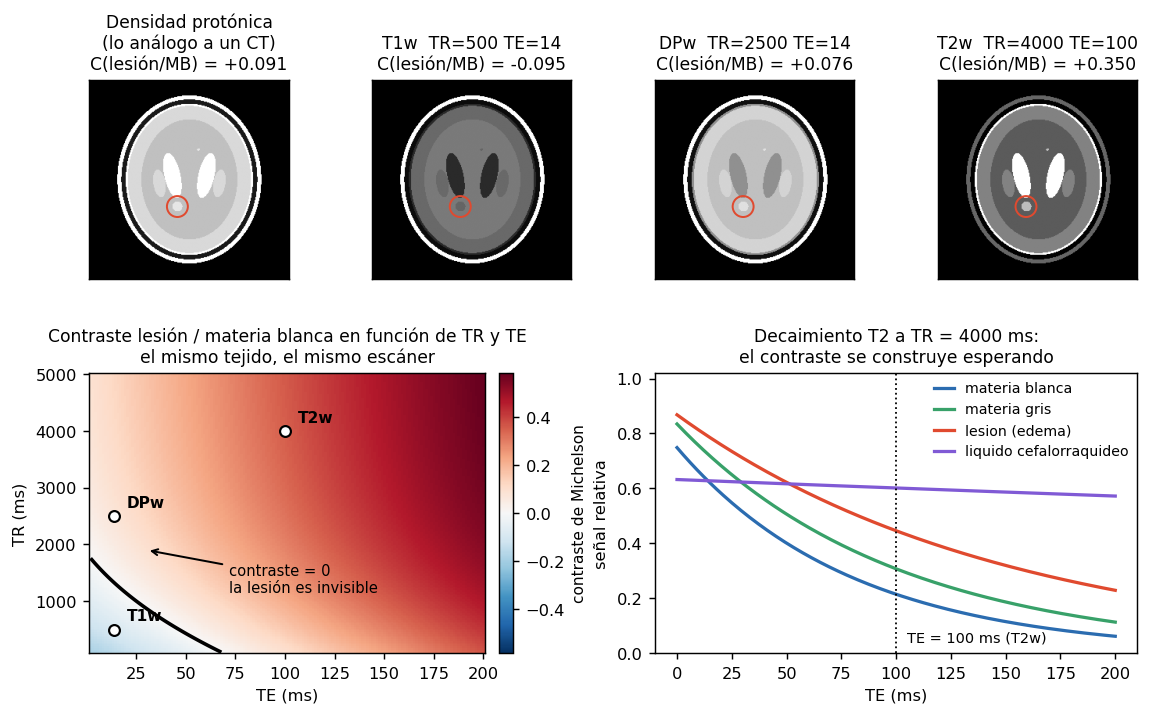

In [5]:
figuras.fig1_contraste()
from IPython.display import Image
Image('figuras/fig1_contraste.png')

## 3. Anatomía del espacio-k

In [6]:
e = E.energia_radial('T2w', N)
print(f'{"radio":>8} {"% muestras":>12} {"% energia":>11}')
for f in (0.01, 0.02, 0.05, 0.10, 0.25, 0.50):
    print(f'{f*100:7.0f}% {e["muestras"][f]*100:11.2f}% {e[f"energia_r{f:.2f}"]*100:10.2f}%')

   radio   % muestras   % energia
      1%        0.01%      70.13%
      2%        0.03%      73.20%
      5%        0.20%      84.45%
     10%        0.78%      85.98%
     25%        4.90%      94.65%
     50%       19.61%      97.50%


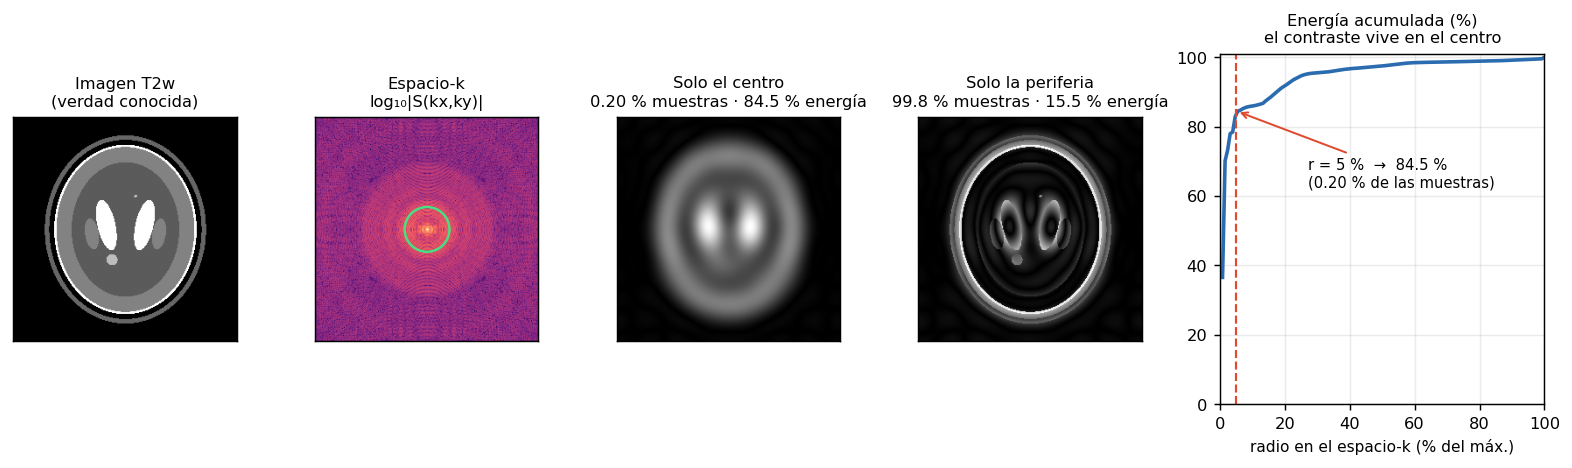

In [7]:
figuras.fig2_kspace()
Image('figuras/fig2_kspace.png')

## 4. Truncamiento: resolución, tiempo y SSIM

Se conservan las *n* líneas centrales de codificación de fase y se rellena con ceros. Métricas contra la reconstrucción completa **sin ruido**.

In [8]:
filas = E.barrido_truncamiento('T2w', N)
print(f'{"lineas":>7} {"frac":>6} {"dy(mm)":>8} {"t(s)":>7} {"t(min)":>7} {"SSIM":>7} {"PSNR":>7} {"NRMSE":>8}')
for r in filas:
    ps = 'inf' if not np.isfinite(r['psnr']) else f"{r['psnr']:.2f}"
    print(f'{r["lineas"]:7d} {r["frac"]:6.2f} {r["res_mm"]:8.2f} {r["t_s"]:7.0f} '
          f'{r["t_s"]/60:7.1f} {r["ssim"]:7.4f} {ps:>7} {r["nrmse"]:8.5f}')

 lineas   frac   dy(mm)    t(s)  t(min)    SSIM    PSNR    NRMSE
    256   1.00     0.94    1024    17.1  1.0000     inf  0.00000
    192   0.75     1.25     768    12.8  0.9406   32.47  0.02379
    160   0.62     1.50     640    10.7  0.9385   30.63  0.02941
    128   0.50     1.88     512     8.5  0.8987   28.83  0.03620
     96   0.38     2.50     384     6.4  0.8632   26.79  0.04574
     64   0.25     3.75     256     4.3  0.8112   24.74  0.05793
     48   0.19     5.00     192     3.2  0.7341   22.91  0.07155
     32   0.12     7.50     128     2.1  0.6513   20.60  0.09336
     24   0.09    10.00      96     1.6  0.6303   19.69  0.10365
     16   0.06    15.00      64     1.1  0.6242   18.92  0.11329


/home/claude/mri/src/mri.py:227: RuntimeWarning: divide by zero encountered in scalar divide
  return float(10 * np.log10((ref.max() - ref.min()) ** 2 / mse))


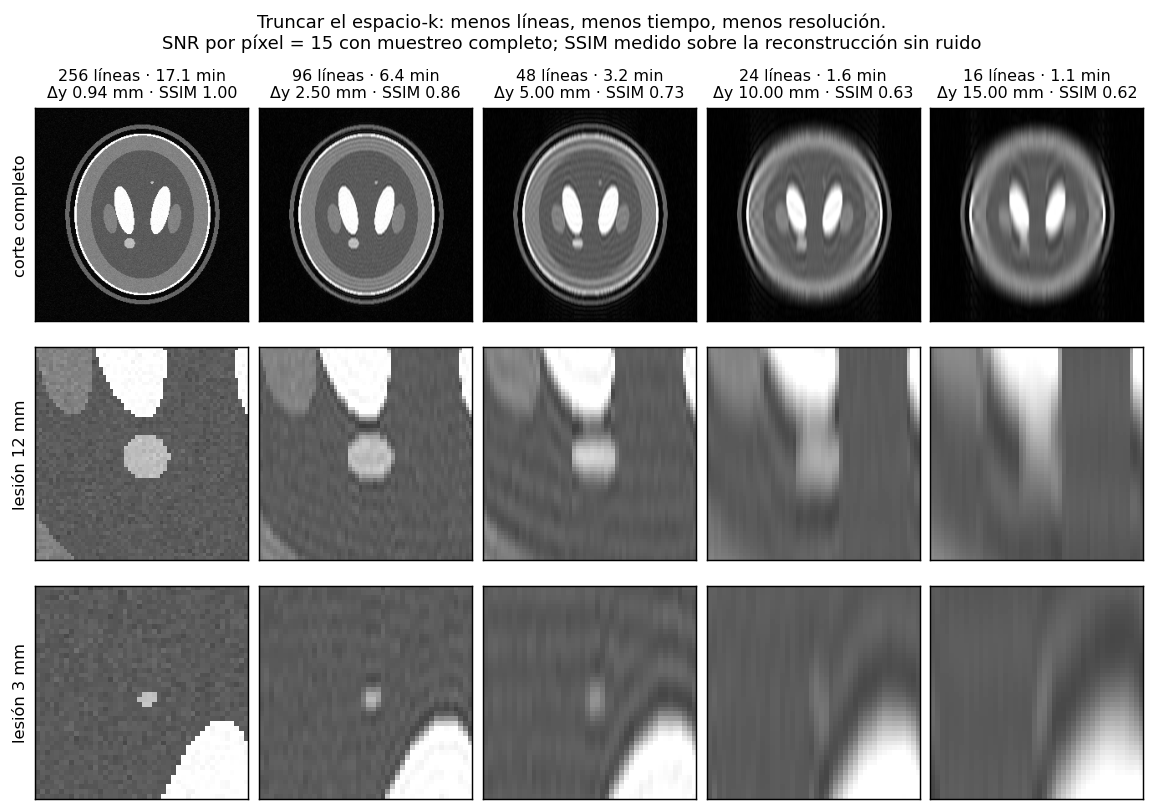

In [9]:
figuras.fig3_truncamiento()
Image('figuras/fig3_truncamiento.png')

## 5. La tarea que importa: detección

Un SSIM no dice si se ve la lesión. Aquí se mide una tarea sí/no con lesión
conocida en posición conocida, con un observador de ROI (no ideal, del tipo que
imita a un lector humano) sobre 600 realizaciones de ruido por condición.

**Nota de diseño.** El primer intento calibró la dificultad subiendo el ruido
hasta que el AUC bajara a 0.90. Eso llevó el SNR por píxel a 0.5, un régimen
donde la operación de magnitud es puro sesgo Rician y no representa ninguna
adquisición clínica. La versión correcta fija el SNR en 15 y ajusta el
**contraste** de la lesión, que es lo que varía de verdad entre pacientes.

In [10]:
img_t2 = mri.imagen_protocolo(lab, 'T2w')
sigma = mri.sigma_para_snr(15, img_t2, lab)
print(f'sigma de espacio-k para SNR=15 por pixel en materia blanca: {sigma:.3f}')

T2_LESION = {'grande': 83.14, 'chica': 85.37}   # calibrados a AUC=0.90 con 256 lineas
for cual, t2v in T2_LESION.items():
    l2 = mri.fantasma_etiquetas(N, lesion_chica=(cual == 'chica'),
                                lesion_grande=(cual == 'grande'))
    im = mri.imagen_protocolo(l2, 'T2w', t2_lesion=t2v, pd_lesion=0.75)
    print(f'  lesion {cual:7s}: T2={t2v:6.2f} ms  contraste vs MB = '
          f'{mri.contraste(im, l2, 6, 5):+.4f}')

sigma de espacio-k para SNR=15 por pixel en materia blanca: 3.659
  lesion grande : T2= 83.14 ms  contraste vs MB = +0.0065
  lesion chica  : T2= 85.37 ms  contraste vs MB = +0.0222


In [11]:
resultados = {}
for cual, t2v in T2_LESION.items():
    resultados[cual] = E.tarea_deteccion(cual, sigma=sigma, n_real=600,
                                         t2_lesion=t2v, pd_lesion=0.75)
    print(f'\nlesion {cual}')
    print(f'{"lineas":>7} {"t(min)":>7} {"AUC":>7} {"IC95":>16} {"d prima":>8}')
    for r in resultados[cual]:
        print(f'{r["lineas"]:7d} {4000*r["lineas"]/60000:7.1f} {r["auc"]:7.3f} '
              f'[{r["ic95"][0]:.3f}, {r["ic95"][1]:.3f}]'.rjust(8) +
              f'{r["dprime"]:8.2f}')


lesion grande
 lineas  t(min)     AUC             IC95  d prima
    256    17.1   0.933 [0.919, 0.946]    2.12
    192    12.8   0.927 [0.913, 0.940]    2.07
    128     8.5   0.927 [0.912, 0.941]    2.06
     96     6.4   0.930 [0.916, 0.944]    2.08
     64     4.3   0.918 [0.903, 0.932]    1.96
     48     3.2   0.924 [0.909, 0.938]    2.04
     32     2.1   0.904 [0.887, 0.920]    1.85
     24     1.6   0.913 [0.897, 0.927]    1.92
     16     1.1   0.857 [0.836, 0.876]    1.51



lesion chica
 lineas  t(min)     AUC             IC95  d prima
    256    17.1   0.907 [0.891, 0.922]    1.89
    192    12.8   0.907 [0.890, 0.923]    1.86
    128     8.5   0.888 [0.870, 0.906]    1.73
     96     6.4   0.881 [0.861, 0.900]    1.65
     64     4.3   0.847 [0.825, 0.868]    1.45
     48     3.2   0.831 [0.808, 0.852]    1.38
     32     2.1   0.746 [0.719, 0.773]    0.93
     24     1.6   0.725 [0.696, 0.753]    0.85
     16     1.1   0.659 [0.629, 0.689]    0.57


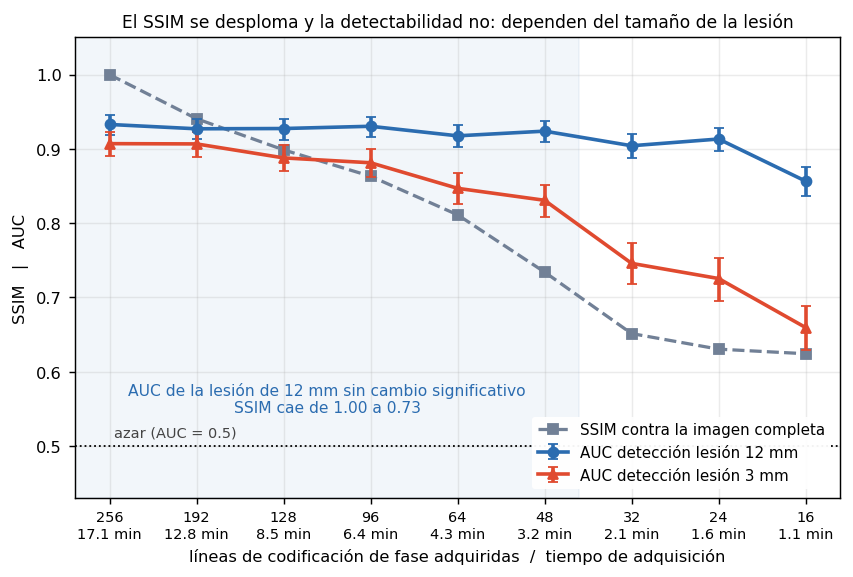

In [12]:
datos = {'sigma': sigma, 't2': T2_LESION,
         'grande': resultados['grande'], 'chica': resultados['chica']}
figuras.fig4_ssim_vs_auc(datos)
Image('figuras/fig4_ssim_vs_auc.png')

## 6. Timbre de Gibbs

Verificación numérica contra el valor teórico de 8.949 %.

In [13]:
print('escalon ideal 1D, malla de 256:')
for r in E.gibbs_escalon(256):
    print(f'  {r["lineas"]:4d} lineas -> {r["sobreimpulso_pct"]:7.3f} %')

def over(Nn, n):
    x = np.zeros(Nn); x[Nn//2:] = 1.0
    X = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x)))
    m = np.zeros(Nn, bool); c = Nn//2; m[c-n//2:c-n//2+n] = True
    y = np.real(np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(X*m))))
    return (y[Nn//2:].max()-1)*100

print('\nmalla de 32768, barriendo el factor de truncamiento:')
for f in (1/8, 1/16, 1/64, 1/256, 1/1024):
    print(f'  N/n = {int(1/f):5d} -> {over(32768, int(32768*f)):7.4f} %')
print('  teorico (Gibbs, limite continuo) = 8.9490 %')

escalon ideal 1D, malla de 256:
   256 lineas ->   0.000 %
   128 lineas ->   6.834 %
    64 lineas ->   8.441 %
    32 lineas ->   8.883 %
    16 lineas ->   9.178 %

malla de 32768, barriendo el factor de truncamiento:
  N/n =     8 ->  8.8187 %
  N/n =    16 ->  8.9164 %
  N/n =    64 ->  8.9472 %
  N/n =   256 ->  8.9529 %
  N/n =  1024 ->  9.0142 %
  teorico (Gibbs, limite continuo) = 8.9490 %


In [14]:
rng = np.random.default_rng(0)
disc = np.where(mri.disco(N, N/2, N/2, 70), 1.0, 0.2)
rec = E.reconstruir(disc, 64, 0.0, rng, N)
p = rec[:, N//2]
alto, bajo = p[70], p[45]
print(f'borde aislado 2D, 64 de 256 lineas -> sobreimpulso = '
      f'{(p[55:70].max()-alto)/(alto-bajo)*100:.2f} %')

g = E.gibbs_en_fantasma('T2w', N, 64)
nivel = g['ref'][45]; seg = g['trunc'][40:51]
print(f'meseta homogenea del fantasma (verdad = {nivel:.4f} constante):')
print(f'  reconstruccion va de {seg.min():.4f} a {seg.max():.4f}  '
      f'({(seg.min()-nivel)/nivel*100:+.1f} % / {(seg.max()-nivel)/nivel*100:+.1f} %)')

borde aislado 2D, 64 de 256 lineas -> sobreimpulso = 5.04 %
meseta homogenea del fantasma (verdad = 0.3070 constante):
  reconstruccion va de 0.2871 a 0.3362  (-6.5 % / +9.5 %)


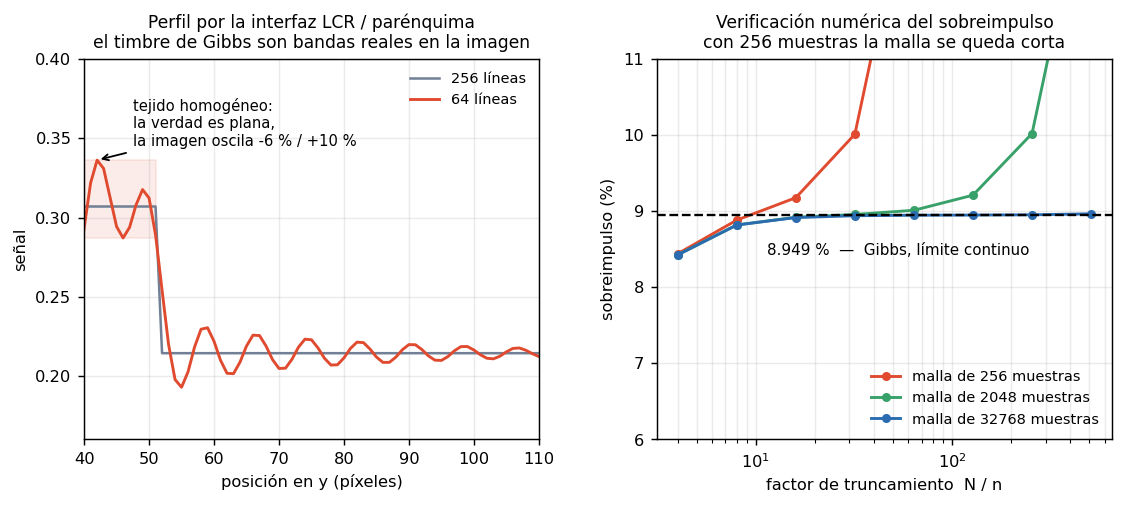

In [15]:
figuras.fig5_gibbs()
Image('figuras/fig5_gibbs.png')

## 7. Tiempos de adquisición

In [16]:
print(f'{"protocolo":>10} {"TR(ms)":>8} {"256 lin":>10} {"128 lin":>10} {"48 lin":>10}')
for p, (TR, TE) in mri.PROTOCOLOS.items():
    t = [mri.tiempo_adquisicion_s(TR, n) for n in (256, 128, 48)]
    print(f'{p:>10} {TR:8.0f} ' + ' '.join(f'{v/60:9.1f}m' for v in t))
print('\nUn CT helicoidal de craneo: del orden de 5-10 s de adquisicion.')

 protocolo   TR(ms)    256 lin    128 lin     48 lin
       T1w      500       2.1m       1.1m       0.4m
       DPw     2500      10.7m       5.3m       2.0m
       T2w     4000      17.1m       8.5m       3.2m

Un CT helicoidal de craneo: del orden de 5-10 s de adquisicion.


In [17]:
os.makedirs('resultados', exist_ok=True)
salida = {
    'energia_radial': {k: v for k, v in e.items() if k not in ('r_px', 'acum')},
    'truncamiento': filas,
    'deteccion': datos,
}
salida['energia_radial']['muestras'] = {str(k): v for k, v in e['muestras'].items()}
with open('resultados/resultados.json', 'w') as f:
    json.dump(salida, f, indent=2, default=float)
print('guardado en resultados/resultados.json')

guardado en resultados/resultados.json
